In [3]:
import numpy as np
import pandas as pd

# Load scaled features
X_scaled = np.load("X_scaled.npy")

# Load cluster labels
labels = np.load("clusters.npy")

print(X_scaled.shape, labels.shape)

(95837, 9) (95837,)


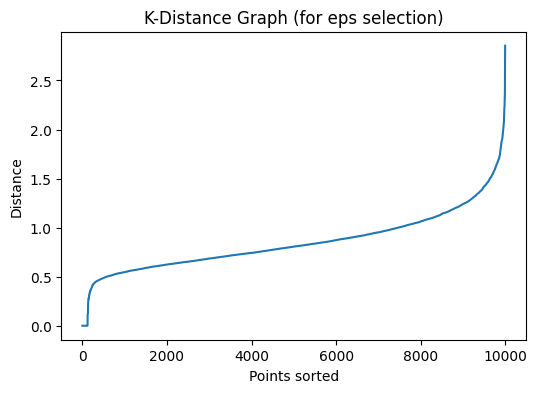


Top DBSCAN Results:
   eps  min_samples  clusters  noise  silhouette
4  1.5           10         2    240    0.209127
3  1.5            5         4    157    0.186533
1  1.0           10         6   2309    0.036560
2  1.0           15         6   2962   -0.039416
0  1.0            5        33   1524   -0.280104

Best Parameters Found:
eps = 1.5, min_samples = 10

Final Model:
Number of clusters: 1
Number of noise points: 347

Cluster distribution:
 0    95490
-1      347
Name: count, dtype: int64

Silhouette Score not valid


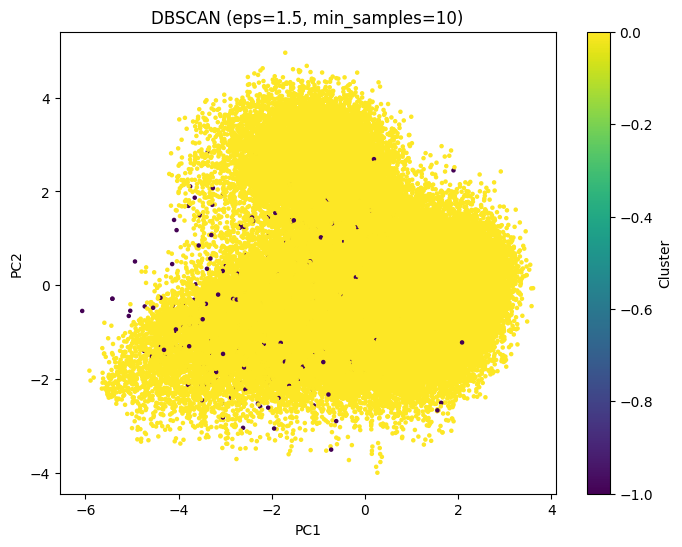

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.utils import resample

# -----------------------------
# 0. Use subset for tuning (IMPORTANT)
# -----------------------------
X_tune = X_scaled[:10000]   # Use only 10k for tuning

# -----------------------------
# 1. K-Distance Graph (eps hint)
# -----------------------------
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_tune)
distances, indices = neighbors_fit.kneighbors(X_tune)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-Distance Graph (for eps selection)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()

# -----------------------------
# 2. Reduced Grid Search (FASTER)
# -----------------------------
eps_values = [1.0, 1.5, 2.0]          # Reduced
min_samples_values = [5, 10, 15]      # Reduced

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_tune)

        n_clusters = len(set(labels) - {-1})
        n_noise = list(labels).count(-1)

        # Skip useless cases early
        if n_clusters < 2 or n_clusters > 50:
            continue

        # -----------------------------
        # Silhouette (FAST SAMPLING)
        # -----------------------------
        try:
            X_sample, labels_sample = resample(
                X_tune, labels,
                n_samples=1000,      # 🔥 reduced from 10k → 1k
                random_state=42
            )
            score = silhouette_score(X_sample, labels_sample)
        except:
            score = -1

        results.append({
            "eps": eps,
            "min_samples": min_s,
            "clusters": n_clusters,
            "noise": n_noise,
            "silhouette": score
        })

# -----------------------------
# 3. Results
# -----------------------------
results_df = pd.DataFrame(results)

if len(results_df) == 0:
    raise ValueError("No valid DBSCAN configuration found. Try different eps range.")

results_df = results_df.sort_values(by="silhouette", ascending=False)

print("\nTop DBSCAN Results:")
print(results_df.head(10))

# -----------------------------
# 4. Pick Best Parameters
# -----------------------------
best_row = results_df.iloc[0]

best_eps = best_row["eps"]
best_min_samples = int(best_row["min_samples"])

print("\nBest Parameters Found:")
print(f"eps = {best_eps}, min_samples = {best_min_samples}")

# -----------------------------
# 5. Train Final Model (FULL DATA)
# -----------------------------
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = dbscan_final.fit_predict(X_scaled)   # FULL dataset here

n_clusters = len(set(labels_db) - {-1})
n_noise = list(labels_db).count(-1)

print(f"\nFinal Model:")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

print("\nCluster distribution:")
print(pd.Series(labels_db).value_counts())

# -----------------------------
# 6. Final Silhouette (sampled)
# -----------------------------
if n_clusters > 1:
    try:
        X_sample, labels_sample = resample(
            X_scaled, labels_db,
            n_samples=1000,
            random_state=42
        )
        final_score = silhouette_score(X_sample, labels_sample)
        print(f"\nFinal Silhouette Score (sampled): {final_score}")
    except:
        print("\nSilhouette computation failed")
else:
    print("\nSilhouette Score not valid")

# -----------------------------
# 7. PCA Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, cmap='viridis', s=5)

plt.title(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label='Cluster')
plt.show()

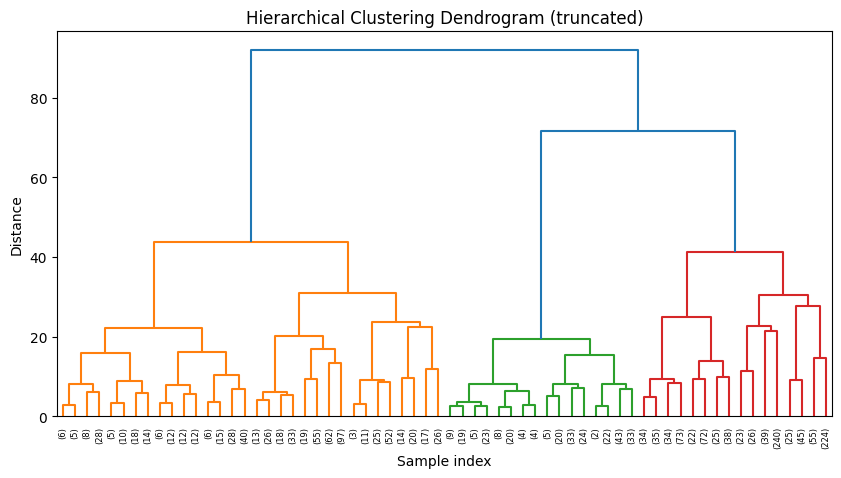


Hierarchical Clustering Results:
   clusters  silhouette
1         3    0.260807
0         2    0.250813
2         4    0.189029
3         5    0.183793
4         6    0.147196

Best number of clusters: 3

Cluster distribution (subset):
0    2823
1    1675
2     502
Name: count, dtype: int64

Final Silhouette Score: 0.26080681210260537


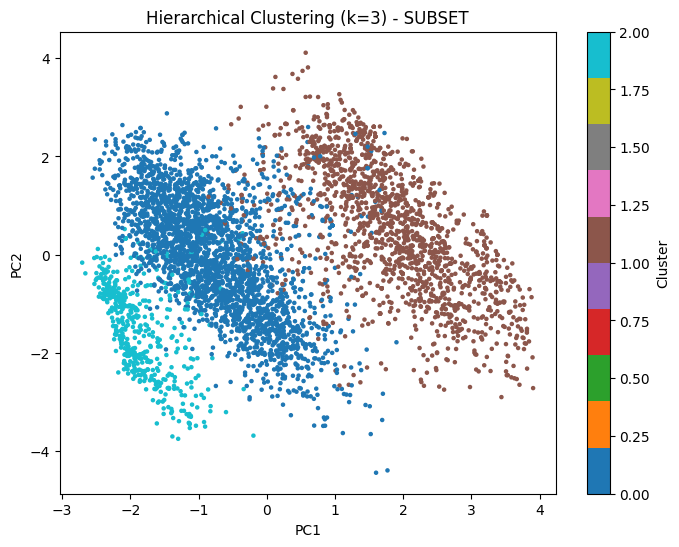

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.utils import resample

from scipy.cluster.hierarchy import dendrogram, linkage

# -----------------------------
# 0. SAFE DATA SUBSET (VERY IMPORTANT)
# -----------------------------
X_tune = X_scaled[:5000]   # DO NOT increase beyond this

# -----------------------------
# 1. Dendrogram (on smaller subset)
# -----------------------------
X_dendro = X_tune[:2000]   # even smaller for dendrogram

linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

# -----------------------------
# 2. Try multiple cluster values
# -----------------------------
cluster_range = [2, 3, 4, 5, 6]

results = []

for k in cluster_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_tune)   # ✅ FIXED (use subset)

    # -----------------------------
    # Silhouette (sampled)
    # -----------------------------
    try:
        X_sil, labels_sil = resample(
            X_tune, labels,
            n_samples=1000,
            random_state=42
        )
        score = silhouette_score(X_sil, labels_sil)
    except:
        score = -1

    results.append({
        "clusters": k,
        "silhouette": score
    })

# -----------------------------
# 3. Results
# -----------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="silhouette", ascending=False)

print("\nHierarchical Clustering Results:")
print(results_df)

# -----------------------------
# 4. Best Cluster Selection
# -----------------------------
best_k = int(results_df.iloc[0]["clusters"])

print(f"\nBest number of clusters: {best_k}")

# -----------------------------
# 5. Final Model (ON SUBSET ONLY)
# -----------------------------
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_hc = final_model.fit_predict(X_tune)

print("\nCluster distribution (subset):")
print(pd.Series(labels_hc).value_counts())

# -----------------------------
# 6. Final Silhouette Score
# -----------------------------
try:
    X_sil, labels_sil = resample(
        X_tune, labels_hc,
        n_samples=1000,
        random_state=42
    )
    final_score = silhouette_score(X_sil, labels_sil)
    print(f"\nFinal Silhouette Score: {final_score}")
except:
    print("\nSilhouette computation failed")

# -----------------------------
# 7. PCA Visualization (subset)
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tune)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_hc, cmap='tab10', s=5)

plt.title(f"Hierarchical Clustering (k={best_k}) - SUBSET")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label='Cluster')
plt.show()